# 🎯 Алгоритм PageRank
## Курс: Информационно-поисковые системы

### Цели занятия:
- Понять математические основы алгоритма PageRank
- Реализовать алгоритм с нуля на Python
- Визуализировать веб-граф и результаты ранжирования
- Экспериментировать с параметрами алгоритма

---

## 📚 Теоретическая справка

**PageRank** — алгоритм определения авторитетности веб-страниц, разработанный основателями Google Ларри Пейджем и Сергеем Брином.

### Основная идея:
> "Важная страница ссылается на другие важные страницы"

### Математическая формула:

$$PR(p_i) = \frac{1-d}{N} + d \sum_{p_j \in M(p_i)} \frac{PR(p_j)}{L(p_j)}$$

Где:
- $PR(p_i)$ — PageRank страницы $p_i$
- $d$ — коэффициент демпфирования (обычно 0.85)
- $N$ — общее количество страниц
- $M(p_i)$ — множество страниц, ссылающихся на $p_i$
- $L(p_j)$ — количество исходящих ссылок со страницы $p_j$

### Интуитивное объяснение:
1. Каждая страница имеет начальный "вес" авторитетности
2. Страницы передают свой вес страницам, на которые ссылаются
3. Процесс повторяется до сходимости
4. Страницы с большим входящим весом от авторитетных источников получают высокий PageRank

In [11]:
# @title 🔧 Импорт библиотек
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML
import warnings
warnings.filterwarnings('ignore')

print("✅ Все библиотеки успешно импортированы!")
print(f"NumPy версия: {np.__version__}")
print(f"NetworkX версия: {nx.__version__}")

✅ Все библиотеки успешно импортированы!
NumPy версия: 2.0.2
NetworkX версия: 3.6.1


📊 Страницы: ['A', 'B', 'C', 'D', 'E']
🔗 Ссылки: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'A'), ('C', 'D'), ('D', 'C'), ('E', 'D'), ('E', 'A')]

📈 Всего страниц: 5
📈 Всего ссылок: 8


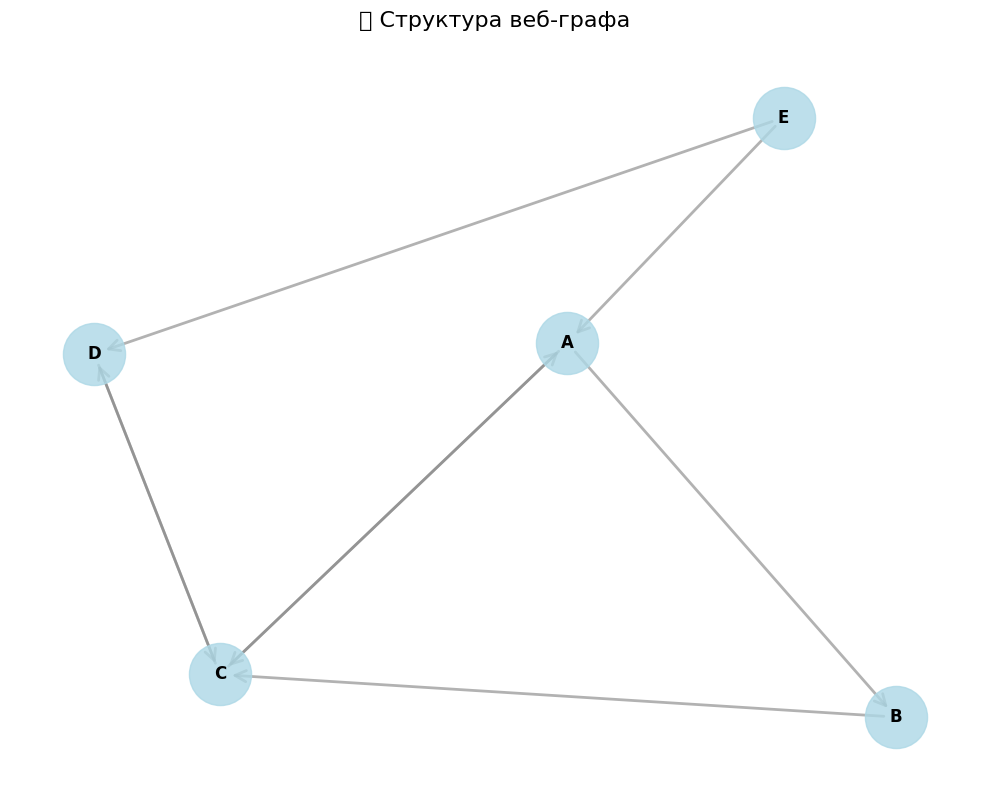

In [12]:
# @title 🌐 Создание тестового веб-графа

class WebGraph:
    """Класс для представления веб-графа"""

    def __init__(self):
        self.pages = []
        self.links = []  # (from_page, to_page)

    def add_page(self, page_name):
        """Добавить страницу"""
        if page_name not in self.pages:
            self.pages.append(page_name)
        return self

    def add_link(self, from_page, to_page):
        """Добавить ссылку между страницами"""
        self.add_page(from_page)
        self.add_page(to_page)
        self.links.append((from_page, to_page))
        return self

    def get_adjacency_matrix(self):
        """Получить матрицу смежности"""
        n = len(self.pages)
        matrix = np.zeros((n, n))
        for from_page, to_page in self.links:
            i = self.pages.index(from_page)
            j = self.pages.index(to_page)
            matrix[i, j] = 1
        return matrix

    def get_outgoing_counts(self):
        """Получить количество исходящих ссылок для каждой страницы"""
        counts = np.zeros(len(self.pages))
        for from_page, to_page in self.links:
            i = self.pages.index(from_page)
            counts[i] += 1
        return counts

    def visualize(self):
        """Визуализировать граф"""
        G = nx.DiGraph()
        G.add_edges_from(self.links)

        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G, seed=42, k=2)

        # Рисуем узлы
        nx.draw_networkx_nodes(G, pos, node_size=2000,
                              node_color='lightblue', alpha=0.8)

        # Рисуем рёбра
        nx.draw_networkx_edges(G, pos, arrowstyle='->',
                              arrowsize=20, edge_color='gray',
                              width=2, alpha=0.6)

        # Рисуем подписи
        nx.draw_networkx_labels(G, pos, font_size=12,
                               font_weight='bold')

        plt.title('🕸️ Структура веб-графа', fontsize=16, pad=20)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

        return G

# Создаём тестовый граф
web_graph = WebGraph()
web_graph.add_link('A', 'B')
web_graph.add_link('A', 'C')
web_graph.add_link('B', 'C')
web_graph.add_link('C', 'A')
web_graph.add_link('C', 'D')
web_graph.add_link('D', 'C')
web_graph.add_link('E', 'D')
web_graph.add_link('E', 'A')

print("📊 Страницы:", web_graph.pages)
print("🔗 Ссылки:", web_graph.links)
print(f"\n📈 Всего страниц: {len(web_graph.pages)}")
print(f"📈 Всего ссылок: {len(web_graph.links)}")

web_graph.visualize()

✅ Сходимость достигнута на итерации 20

🏆 РЕЗУЛЬТАТЫ RANKING


,Страница,PageRank,Ранг
0,C,0.411859,1
1,A,0.217790,2
2,D,0.217790,3
3,B,0.122561,4
4,E,0.030000,5


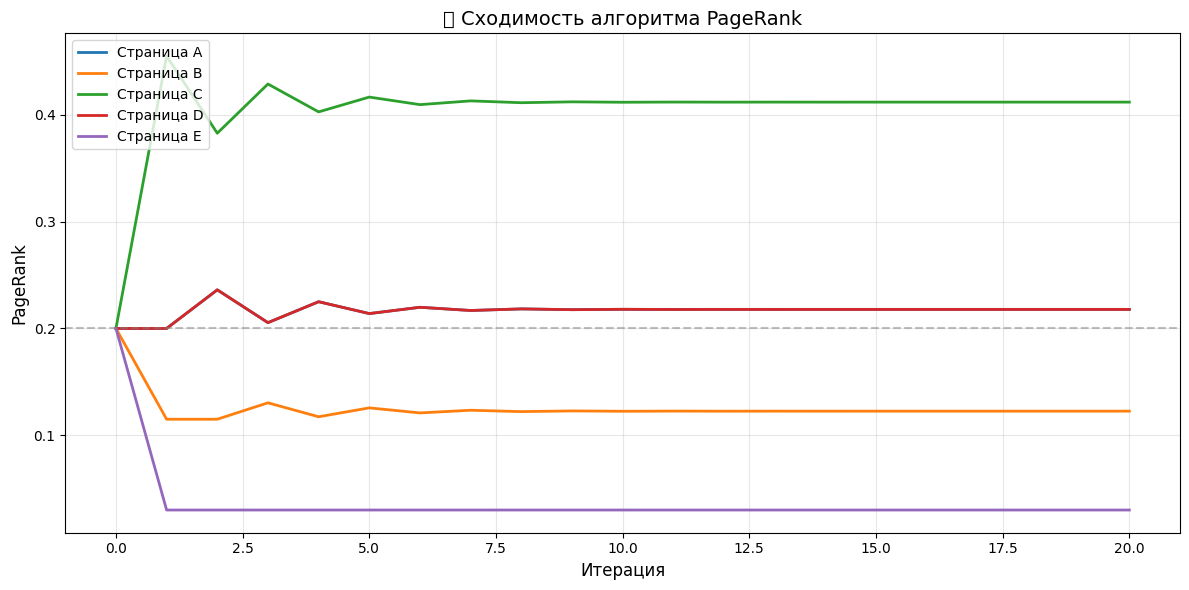

In [13]:
# @title 🧮 Реализация PageRank с нуля

class PageRankCalculator:
    """Калькулятор PageRank"""

    def __init__(self, web_graph, damping_factor=0.85, max_iterations=100, tolerance=1e-6):
        self.graph = web_graph
        self.d = damping_factor  # Коэффициент демпфирования
        self.max_iter = max_iterations
        self.tol = tolerance
        self.n = len(web_graph.pages)
        self.pages = web_graph.pages

    def calculate(self):
        """Вычислить PageRank"""
        n = self.n

        # Инициализация: равный вес для всех страниц
        pr = np.ones(n) / n

        # Матрица переходов
        adj_matrix = self.graph.get_adjacency_matrix()
        outgoing = self.graph.get_outgoing_counts()

        # История сходимости
        history = [pr.copy()]

        for iteration in range(self.max_iter):
            new_pr = np.zeros(n)

            # Основная формула PageRank
            for j in range(n):  # Для каждой целевой страницы
                for i in range(n):  # Проверяем все источники
                    if adj_matrix[i, j] == 1 and outgoing[i] > 0:
                        new_pr[j] += pr[i] / outgoing[i]

            # Применяем формулу с демпфированием
            new_pr = (1 - self.d) / n + self.d * new_pr

            # Нормализация (на случай dangling nodes)
            new_pr = new_pr / new_pr.sum()

            history.append(new_pr.copy())

            # Проверка сходимости
            if np.abs(new_pr - pr).sum() < self.tol:
                print(f"✅ Сходимость достигнута на итерации {iteration + 1}")
                break

            pr = new_pr

        if iteration == self.max_iter - 1:
            print(f"⚠️ Достигнуто максимальное количество итераций: {self.max_iter}")

        self.pr_values = pr
        self.history = history

        return pr

    def get_results_dataframe(self):
        """Получить результаты в виде DataFrame"""
        df = pd.DataFrame({
            'Страница': self.pages,
            'PageRank': self.pr_values,
            'Ранг': np.argsort(np.argsort(-self.pr_values)) + 1
        })
        df = df.sort_values('PageRank', ascending=False)
        df['PageRank'] = df['PageRank'].round(6)
        return df.reset_index(drop=True)

    def plot_convergence(self):
        """Визуализировать сходимость"""
        history_array = np.array(self.history)

        plt.figure(figsize=(12, 6))
        for i, page in enumerate(self.pages):
            plt.plot(history_array[:, i], label=f'Страница {page}', linewidth=2)

        plt.xlabel('Итерация', fontsize=12)
        plt.ylabel('PageRank', fontsize=12)
        plt.title('📈 Сходимость алгоритма PageRank', fontsize=14)
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=1/len(self.pages), color='gray', linestyle='--',
                   label='Начальное значение', alpha=0.5)
        plt.tight_layout()
        plt.show()

# Запускаем расчёт
pr_calculator = PageRankCalculator(web_graph, damping_factor=0.85)
pr_values = pr_calculator.calculate()

print("\n" + "="*50)
print("🏆 РЕЗУЛЬТАТЫ RANKING")
print("="*50)
results_df = pr_calculator.get_results_dataframe()
display(results_df)

pr_calculator.plot_convergence()

✅ Сходимость достигнута на итерации 12
✅ Сходимость достигнута на итерации 20
✅ Сходимость достигнута на итерации 23


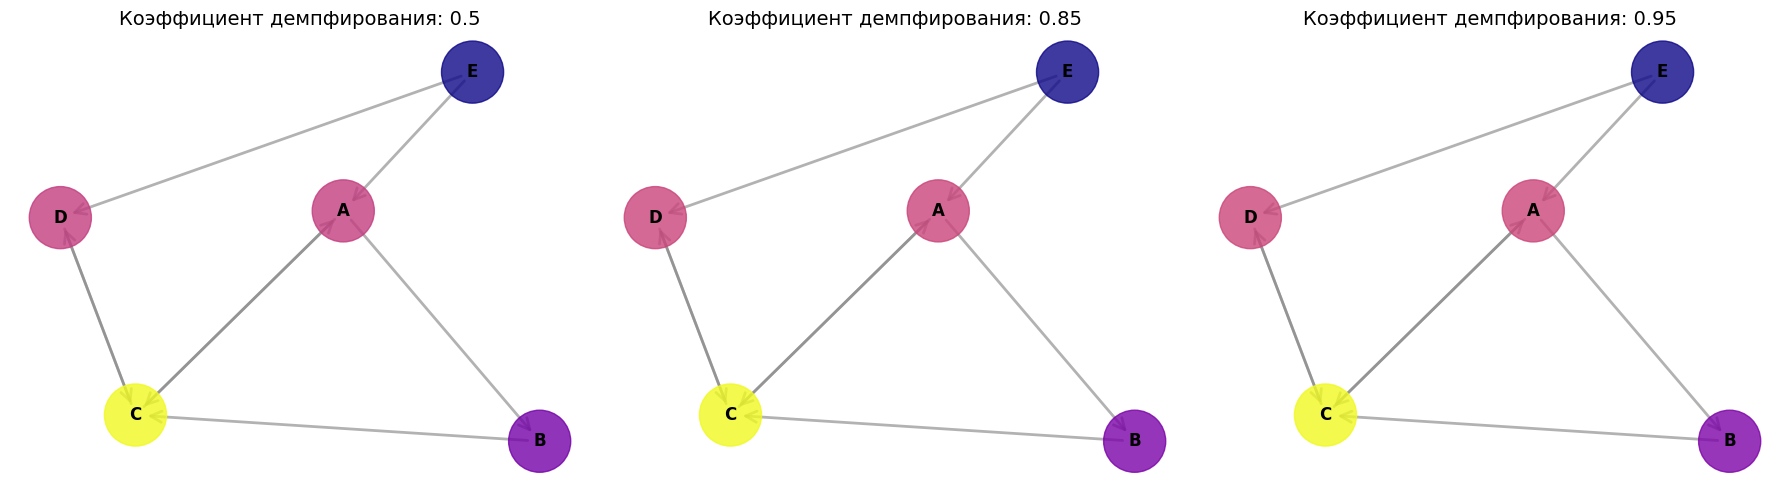


📊 Сравнение PageRank при разных коэффициентах демпфирования:


,Страница,d=0.5,d=0.85,d=0.95
0,A,0.208,0.217790,0.220741
1,B,0.152,0.122561,0.114852
2,C,0.332,0.411859,0.433666
3,D,0.208,0.217790,0.220741
4,E,0.100,0.030000,0.010000


,Страница,d=0.5,d=0.85,d=0.95
0,A,0.208,0.217790,0.220741
1,B,0.152,0.122561,0.114852
2,C,0.332,0.411859,0.433666
3,D,0.208,0.217790,0.220741
4,E,0.100,0.030000,0.010000


In [14]:
# @title 🎛️ Эксперимент: Влияние коэффициента демпфирования

def compare_damping_factors(graph, factors=[0.5, 0.85, 0.95]):
    """Сравнить результаты при разных коэффициентах демпфирования"""

    fig, axes = plt.subplots(1, len(factors), figsize=(18, 5))
    if len(factors) == 1:
        axes = [axes]

    results = []

    for idx, d in enumerate(factors):
        calc = PageRankCalculator(graph, damping_factor=d)
        pr = calc.calculate()

        df = pd.DataFrame({
            'Страница': graph.pages,
            f'd={d}': pr
        })
        results.append(df)

        # Визуализация на графе
        G = nx.DiGraph()
        G.add_edges_from(graph.links)
        pos = nx.spring_layout(G, seed=42, k=2)

        node_colors = [pr[graph.pages.index(node)] for node in G.nodes()]

        nx.draw_networkx_nodes(G, pos, node_size=2000,
                              node_color=node_colors,
                              cmap='plasma', alpha=0.8, ax=axes[idx])
        nx.draw_networkx_edges(G, pos, arrowstyle='->',
                              arrowsize=20, edge_color='gray',
                              width=2, alpha=0.6, ax=axes[idx])
        nx.draw_networkx_labels(G, pos, font_size=12,
                               font_weight='bold', ax=axes[idx])

        axes[idx].set_title(f'Коэффициент демпфирования: {d}', fontsize=14)
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Сводная таблица
    merged_df = results[0]
    for df in results[1:]:
        merged_df = merged_df.merge(df, on='Страница')

    print("\n📊 Сравнение PageRank при разных коэффициентах демпфирования:")
    display(merged_df.round(6))

    return merged_df

compare_damping_factors(web_graph)

📊 Страницы: ['A', 'B', 'C', 'D', 'E']
🔗 Ссылки: [('A', 'B'), ('B', 'C'), ('C', 'C'), ('D', 'A'), ('E', 'A')]

📈 Количество исходящих ссылок:
  A: 1 ссылок ✅ OK
  B: 1 ссылок ✅ OK
  C: 1 ссылок ✅ OK
  D: 1 ссылок ✅ OK
  E: 1 ссылок ✅ OK


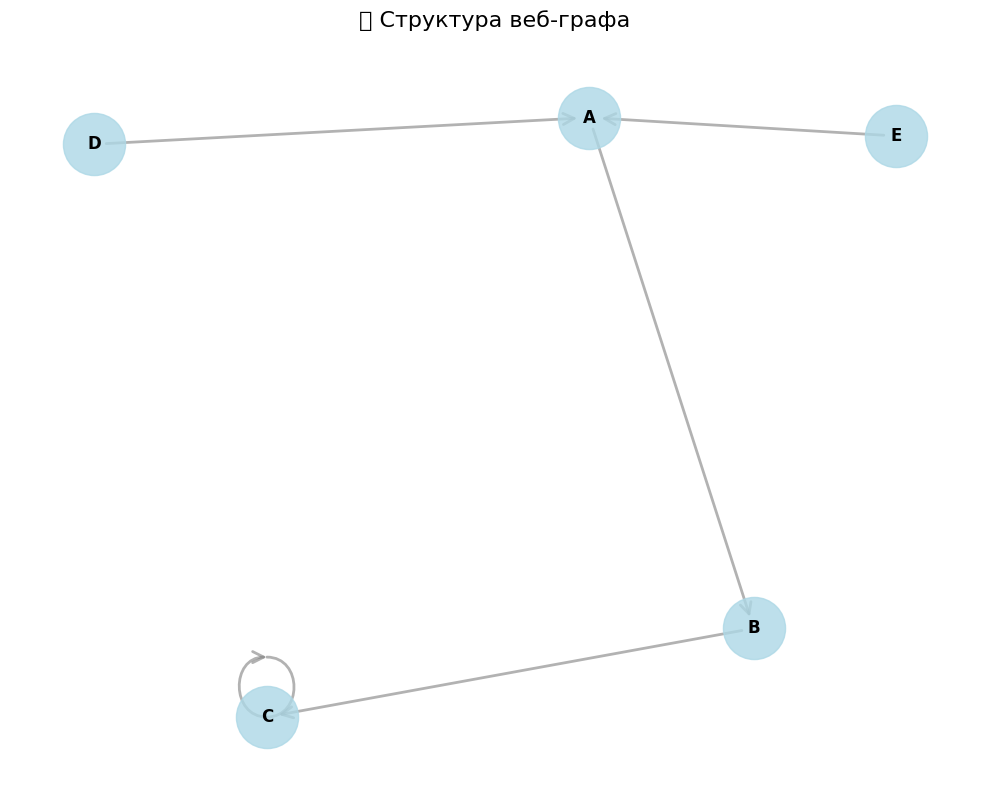

✅ Сходимость достигнута на итерации 4


,Страница,PageRank,Ранг
0,C,0.76015,1
1,B,0.09885,2
2,A,0.08100,3
3,D,0.03000,4
4,E,0.03000,5


In [15]:
# @title 🔍 Анализ: Dangling Nodes (висячие узлы)

# Создаём граф с висячими узлами (страницы без исходящих ссылок)
dangling_graph = WebGraph()
dangling_graph.add_link('A', 'B')
dangling_graph.add_link('B', 'C')
dangling_graph.add_link('C', 'C')  # Самоссылка
dangling_graph.add_link('D', 'A')  # D - висячий узел (нет исходящих)
dangling_graph.add_link('E', 'A')  # E - висячий узел

print("📊 Страницы:", dangling_graph.pages)
print("🔗 Ссылки:", dangling_graph.links)

outgoing = dangling_graph.get_outgoing_counts()
print("\n📈 Количество исходящих ссылок:")
for i, page in enumerate(dangling_graph.pages):
    status = "⚠️ ВИСЯЧИЙ" if outgoing[i] == 0 else "✅ OK"
    print(f"  {page}: {int(outgoing[i])} ссылок {status}")

dangling_graph.visualize()

# Расчёт PageRank
pr_calc = PageRankCalculator(dangling_graph)
pr_calc.calculate()
display(pr_calc.get_results_dataframe())

In [16]:
# @title 📊 Сравнение с NetworkX

# Используем встроенную реализацию NetworkX
G_nx = nx.DiGraph()
G_nx.add_edges_from(web_graph.links)

# Расчёт PageRank через NetworkX
pr_nx = nx.pagerank(G_nx, alpha=0.85, max_iter=100, tol=1e-6)

# Сравниваем с нашей реализацией
comparison_df = pd.DataFrame({
    'Страница': web_graph.pages,
    'Наша реализация': pr_calculator.pr_values,
    'NetworkX': [pr_nx[page] for page in web_graph.pages]
})
comparison_df['Разница'] = abs(comparison_df['Наша реализация'] - comparison_df['NetworkX'])
comparison_df = comparison_df.sort_values('Страница')

print("🔍 Сравнение нашей реализации с NetworkX:")
display(comparison_df.round(8))

print(f"\n✅ Максимальная разница: {comparison_df['Разница'].max():.10f}")
print(f"✅ Средняя разница: {comparison_df['Разница'].mean():.10f}")

if comparison_df['Разница'].max() < 1e-5:
    print("\n🎉 Реализации практически идентичны!")

🔍 Сравнение нашей реализации с NetworkX:


,Страница,Наша реализация,NetworkX,Разница
0,A,0.217790,0.217790,3.100000e-07
1,B,0.122561,0.122561,3.000000e-07
2,C,0.411859,0.411859,3.300000e-07
3,D,0.217790,0.217790,3.100000e-07
4,E,0.030000,0.030000,0.000000e+00



✅ Максимальная разница: 0.0000003305
✅ Средняя разница: 0.0000002505

🎉 Реализации практически идентичны!


In [18]:
# @title 🎮 Интерактивный эксперимент

from ipywidgets import interact, FloatSlider, IntSlider

def interactive_pagerank(damping=0.85, iterations=50):
    calc = PageRankCalculator(web_graph,
                             damping_factor=damping,
                             max_iterations=iterations)
    pr = calc.calculate()

    df = pd.DataFrame({
        'Страница': web_graph.pages,
        'PageRank': pr.round(6)
    }).sort_values('PageRank', ascending=False)

    display(df.reset_index(drop=True))

    # Визуализация
    G = nx.DiGraph()
    G.add_edges_from(web_graph.links)
    pos = nx.spring_layout(G, seed=42, k=2)

    plt.figure(figsize=(10, 8))
    node_colors = [pr[web_graph.pages.index(node)] for node in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_size=2000,
                          node_color=node_colors,
                          cmap='viridis', alpha=0.8)
    nx.draw_networkx_edges(G, pos, arrowstyle='->',
                          arrowsize=20, edge_color='gray',
                          width=2, alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

    plt.title(f'PageRank (d={damping}, iter={iterations})', fontsize=16)
    plt.axis('off')

    # --- Правильное создание colorbar ---
    sm = plt.cm.ScalarMappable(
        cmap='viridis',
        norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors))
    )
    sm.set_array([])                      # необходимо для colorbar
    plt.colorbar(sm, label='PageRank', ax=plt.gca(), pad=0.05)
    # ------------------------------------

    plt.tight_layout()
    plt.show()

interact(interactive_pagerank,
         damping=FloatSlider(min=0.1, max=0.99, step=0.05, value=0.85),
         iterations=IntSlider(min=10, max=100, step=10, value=50))

interactive(children=(FloatSlider(value=0.85, description='damping', max=0.99, min=0.1, step=0.05), IntSlider(…

<function __main__.interactive_pagerank(damping=0.85, iterations=50)>

# @title 📝 Задания для самостоятельной работы

from IPython.display import Markdown

markdown_content = """
## 🎓 Задания для студентов

### Задание 1: Базовое понимание
1. Объясните, почему коэффициент демпфирования обычно равен 0.85?
2. Что произойдёт, если установить d = 0 или d = 1?
3. Почему необходима нормализация PageRank?

### Задание 2: Модификация графа
Создайте свой веб-граф с 6-8 страницами и проанализируйте:
- Какие страницы получили наивысший PageRank?
- Как изменение структуры ссылок влияет на ранжирование?

### Задание 3: Исследование сходимости
- При каком количестве итераций достигается сходимость?
- Как tolerance влияет на точность и скорость?

### Задание 4: Критические узлы
- Найдите страницу, удаление которой максимально изменит PageRank других
- Объясните почему это происходит

### Задание 5: Реальный кейс
Предложите, как можно модифицировать PageRank для:
- Борьбы со спамом (link farms)
- Учёта тематики страниц (Topic-Sensitive PageRank)
- Учёта времени (Freshness Factor)

---

## 📚 Дополнительные материалы

- [Оригинальная статья PageRank (1998)](https://web.stanford.edu/~backrub/google.html)
- [Документация NetworkX](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html)
- [Визуализация алгоритма](https://pr.algolia.com/)

---

**Автор:** Курс "Информационно-поисковые системы"  
**Версия:** 1.0  
**Лицензия:** CC BY-SA 4.0
"""

display(Markdown(markdown_content))